In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import networkx as nx
from scipy.stats import wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [2]:
target_long_df = pd.read_parquet(
    "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_target_contacts_long_5A.parquet"
)

In [3]:
rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/pairwise_method_comparisons_rank1_with_binder_ca_rmsd_and_target_shell_rmsd.parquet")

In [4]:
pocket_aligned_rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/directed_method_comparisons_rank1_with_target_shell_rmsd.parquet")

pocket_aligned_rmsd_df.columns.to_list()

['binder_sequence',
 'reference_method',
 'query_method',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell']

In [5]:
seq = "VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERVDLFA"
rmsd_col = "binder_ca_rmsd_align_target_shell"

af3_seq_df = pocket_aligned_rmsd_df[
    (pocket_aligned_rmsd_df["binder_sequence"] == seq) &
    ((pocket_aligned_rmsd_df["reference_method"] == "AF3"))
].copy()


result = af3_seq_df[[
    "binder_sequence",
    "reference_method",
    "query_method",
    rmsd_col
]]

print(result)

                                         binder_sequence reference_method  \
28310  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28311  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28312  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28313  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28314  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28315  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28316  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   
28317  VKGHFAECPEQYKHYCIHGTCRYVIAENTPSCVCDEGYIGARCERV...              AF3   

      query_method  binder_ca_rmsd_align_target_shell  
28310          AF2                           1.429118  
28311      Boltz-2                           1.942905  
28312       Chai-1                           1.864885  
28313   HelixFold3                           1.778546  
28314          OF2        

In [6]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [7]:
rmsd_merged = rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [8]:
pocket_merged = pocket_aligned_rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
pocket_merged = pocket_merged.drop(columns=["sequence"])

In [9]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [10]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [11]:
plot_pocket = pocket_merged[pocket_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [12]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()
print(plot_target.columns)

Index(['binder_sequence', 'method', 'path', 'file_type', 'binder_chain_id',
       'target_chain_id', 'score', 'score_name', 'contact_cutoff',
       'target_resseq', 'target_icode', 'design_class', 'binding'],
      dtype='str')


In [13]:
# Create contact sets: (binder, method) → set of residues
contact_sets = (
    plot_target
    .groupby(["binder_sequence", "method", "binding"])["target_resseq"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="contact_set")
)

rows = []

for binder, group in contact_sets.groupby("binder_sequence"):
    methods = group["method"].values
    sets = group["contact_set"].values
    
    # all rows in group have same Binding → just take first
    binding = group["binding"].iloc[0]
    
    for (m1, s1), (m2, s2) in combinations(zip(methods, sets), 2):
        if len(s1 | s2) == 0:
            jaccard = 0.0
        else:
            jaccard = len(s1 & s2) / len(s1 | s2)
        
        rows.append({
            "binder_sequence": binder,
            "method_1": m1,
            "method_2": m2,
            "jaccard": jaccard,
            "Binding": binding   # ← add it here
        })

jaccard_df = pd.DataFrame(rows)

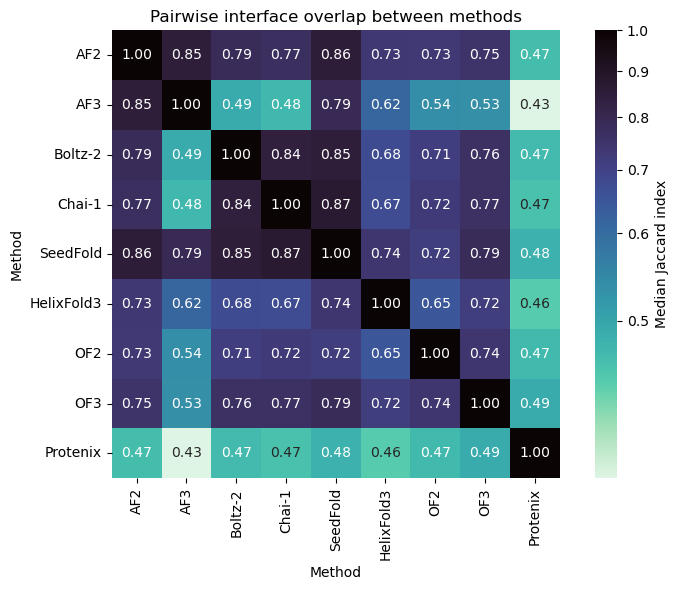

In [14]:
# Median Jaccard per method pair
jaccard_matrix = (
    jaccard_df
    .groupby(["method_1", "method_2"])["jaccard"]
    .median()
    .unstack()
)

# Make symmetric
jaccard_matrix = jaccard_matrix.combine_first(jaccard_matrix.T)

# Use one shared method order
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

jaccard_matrix = jaccard_matrix.reindex(
    index=method_order,
    columns=method_order
)

norm = colors.PowerNorm(gamma=0.5)


# Fill diagonal
for m in method_order:
    jaccard_matrix.loc[m, m] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

plt.title("Pairwise interface overlap between methods")
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

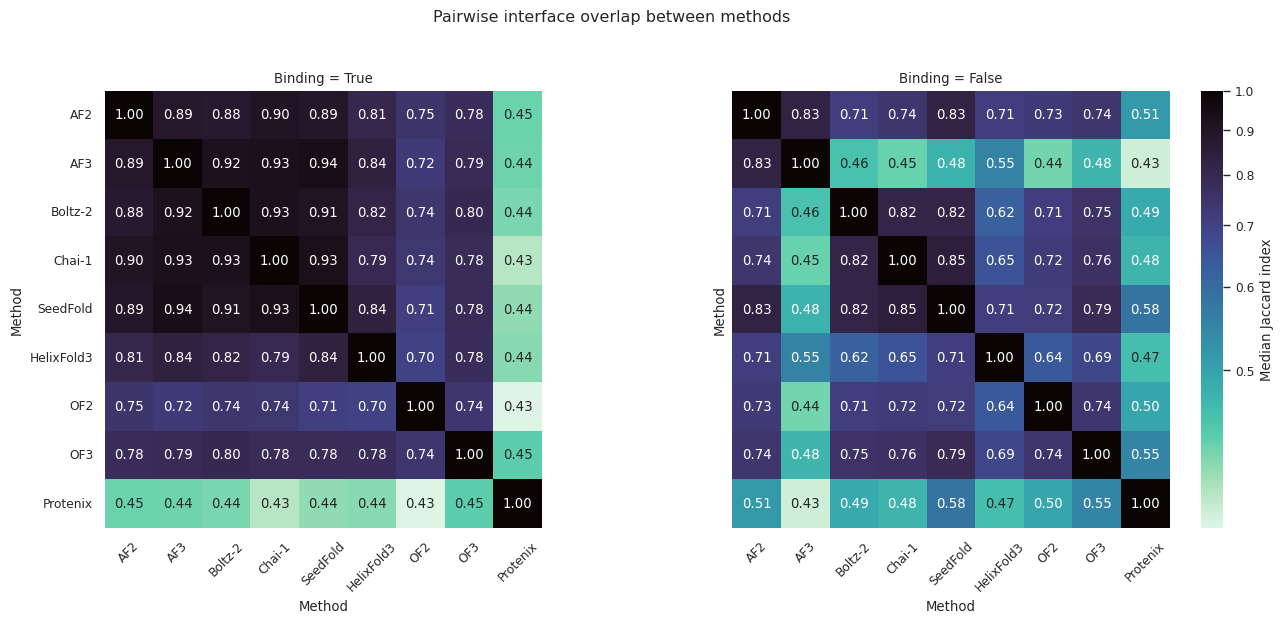

In [15]:
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
def make_jaccard_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])["jaccard"]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 1.0

    return matrix


binding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == True])
nonbinding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == False])

norm = colors.PowerNorm(gamma=0.5)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed colormap
    vmin=0.4,
    vmax=1,
    square=True,
    cbar=False,
    norm=norm
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed here too
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Pairwise interface overlap between methods", y=1.03)

plt.tight_layout()
plt.show()

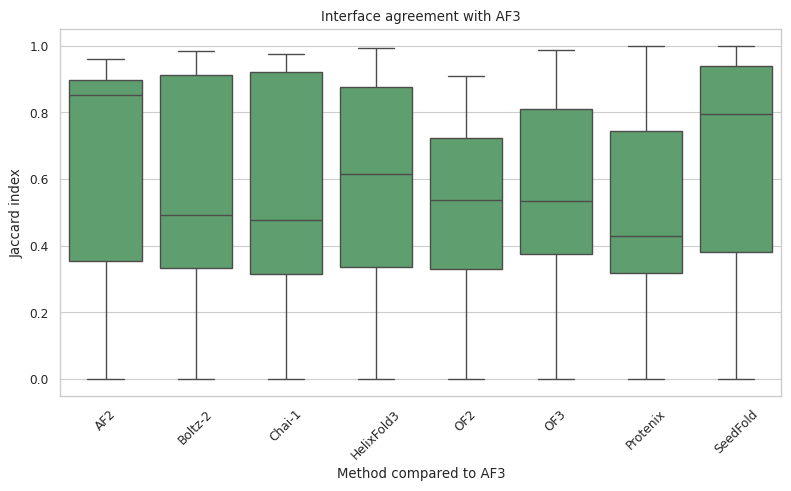

In [16]:
ref = "AF3"

ref_df = jaccard_df[
    (jaccard_df["method_1"] == ref) |
    (jaccard_df["method_2"] == ref)
].copy()

ref_df["other_method"] = ref_df.apply(
    lambda row: row["method_2"] if row["method_1"] == ref else row["method_1"],
    axis=1
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=ref_df,
    x="other_method",
    y="jaccard",
    color="#55A868",
)

plt.ylabel("Jaccard index")
plt.xlabel("Method compared to AF3")
plt.title("Interface agreement with AF3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

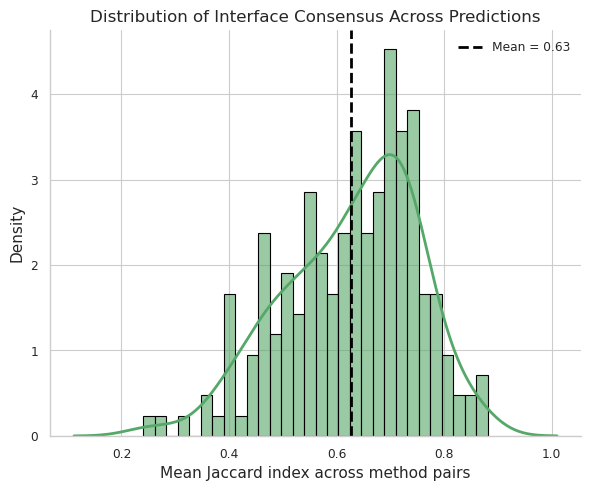

In [17]:
binder_consensus = (
    jaccard_df
    .groupby("binder_sequence")["jaccard"]
    .mean()
    .reset_index(name="mean_jaccard")
)
mean_val = binder_consensus["mean_jaccard"].mean()

sns.set(style="whitegrid", context="paper")

plt.figure(figsize=(6, 5))

# Histogram
sns.histplot(
    data=binder_consensus,
    x="mean_jaccard",
    bins=30,
    stat="density",        # important for overlaying KDE
    alpha=0.6,
    edgecolor="black",
    color="#55A868"
)

# KDE line (smooth distribution)
sns.kdeplot(
    data=binder_consensus,
    x="mean_jaccard",
    linewidth=2,
    color="#55A868"
)

# Mean line
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.2f}",
    color="black"
)

# Labels
plt.xlabel("Mean Jaccard index across method pairs", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Distribution of Interface Consensus Across Predictions", fontsize=12)

# Legend
plt.legend(frameon=False)

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

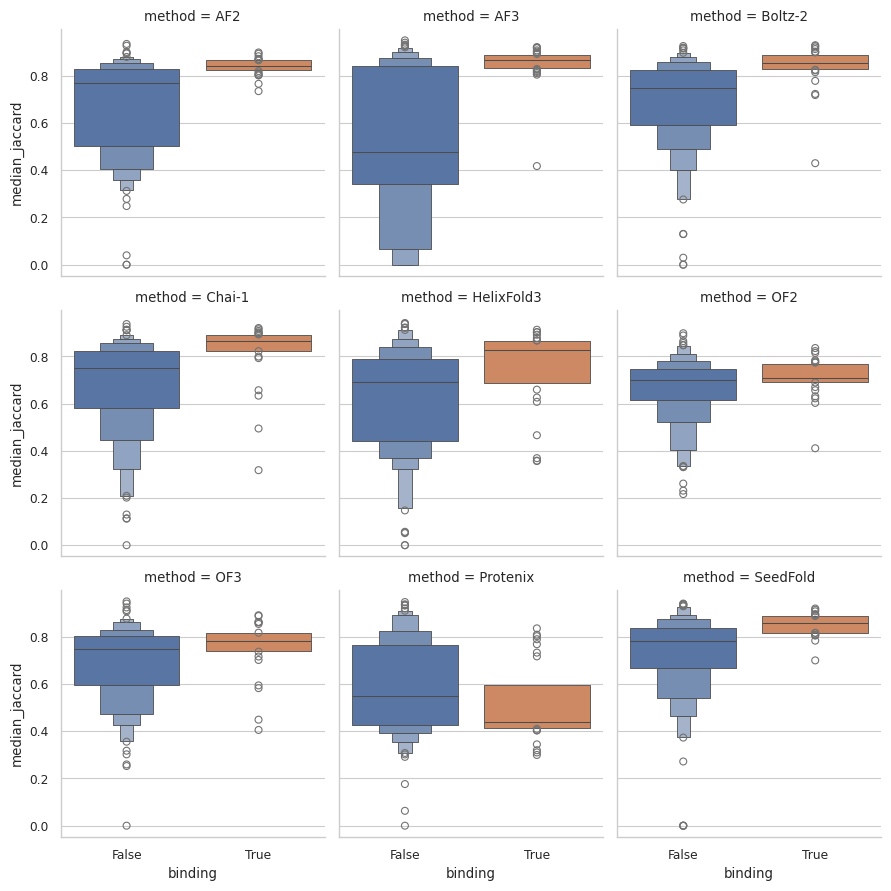

In [18]:
binder_binding = df_csv[["sequence", "binding"]].copy().drop_duplicates().rename(columns={"sequence": "binder_sequence"})

jaccard_long = pd.concat([
    jaccard_df.rename(columns={"method_1": "method", "method_2": "other"}),
    jaccard_df.rename(columns={"method_2": "method", "method_1": "other"})
])

model_jaccard = (
    jaccard_long
    .groupby(["binder_sequence", "method"])["jaccard"]
    .median()
    .reset_index()
    .rename(columns={"jaccard": "median_jaccard"}))

# Add binding label
model_jaccard = model_jaccard.merge(
    binder_binding,
    on="binder_sequence"
)
palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.catplot(
    data=model_jaccard,
    x="binding",
    y="median_jaccard",
    col="method",
    kind="boxen",
    col_wrap=3,
    height=3,
    sharey=True,
    hue="binding",        # ← important
    palette=palette,      # ← your colors
    legend=False          # ← avoid duplicate legend per facet
)

plt.show()

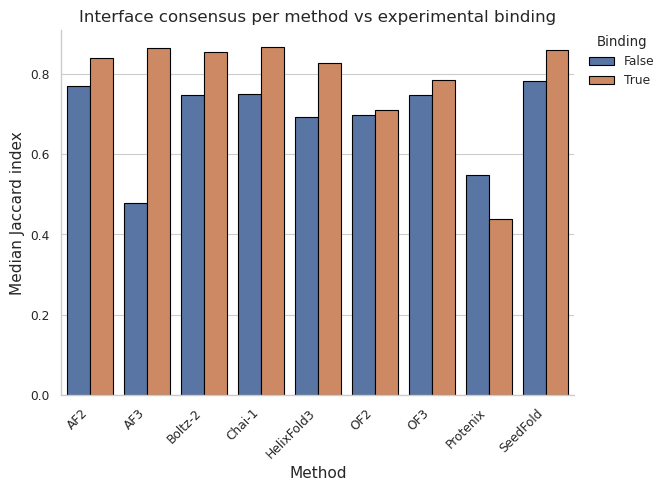

In [19]:
summary = (
    model_jaccard
    .groupby(["method", "binding"])["median_jaccard"]
    .median()
    .reset_index()
)

palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=summary,
    x="method",
    y="median_jaccard",
    hue="binding",
    palette=palette,
    edgecolor="black"
)

# Improve labels
ax.set_xlabel("Method", fontsize=11)
ax.set_ylabel("Median Jaccard index", fontsize=11)
ax.set_title("Interface consensus per method vs experimental binding", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45, ha="right")

# Clean legend
plt.legend(
    title="Binding",
    frameon=False,
    bbox_to_anchor=(1.02, 1),  # move outside right
    loc="upper left",
    borderaxespad=0
)

# Remove top/right spines
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

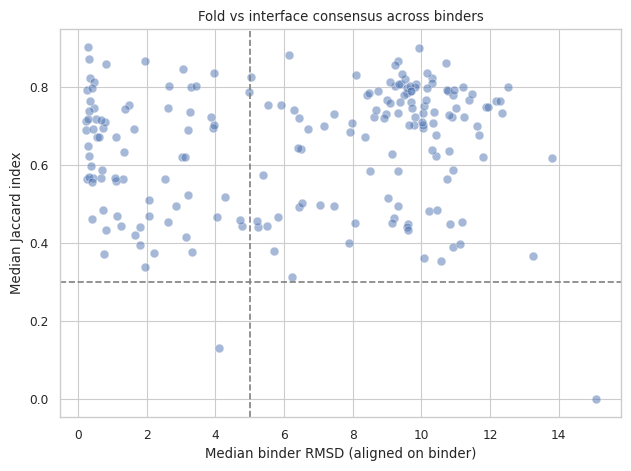

In [20]:
# Jaccard summary per binder
binder_jaccard_summary = (
    jaccard_df
    .groupby("binder_sequence", as_index=False)["jaccard"]
    .median()
    .rename(columns={"jaccard": "median_jaccard"})
)

# RMSD summary per binder (aligned on binder)
binder_rmsd_summary = (
    plot_rmsd
    .groupby("binder_sequence", as_index=False)["binder_ca_rmsd_align_binder"]
    .median()
    .rename(columns={"binder_ca_rmsd_align_binder": "median_binder_rmsd"})
)

# Merge
consensus_df = binder_jaccard_summary.merge(
    binder_rmsd_summary,
    on="binder_sequence",
    how="inner"
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.scatterplot(
    data=consensus_df,
    x="median_binder_rmsd",
    y="median_jaccard",
    alpha=0.5,
    s=40
)
plt.axvline(x=5, linestyle="--", color="grey")   # example RMSD cutoff
plt.axhline(y=0.3, linestyle="--", color="grey") # example Jaccard cutoff
plt.xlabel("Median binder RMSD (aligned on binder)")
plt.ylabel("Median Jaccard index")
plt.title("Fold vs interface consensus across binders")
plt.tight_layout()
plt.show()

In [21]:
rmsd_binder = plot_rmsd.copy()

# Drop old/incorrect column if present
rmsd_binder = rmsd_binder.drop(
    columns=["binder_ca_rmsd_align_target_shell"],
    errors="ignore"
)

rmsd_binder = rmsd_binder.rename(
    columns={"binder_ca_rmsd_align_binder": "rmsd_binder_aligned"}
)

rmsd_pocket = plot_pocket.copy()

rmsd_pocket = rmsd_pocket.rename(
    columns={
        "reference_method": "method_1",
        "query_method": "method_2",
        "binder_ca_rmsd_align_target_shell": "rmsd_pocket_aligned"
    }
)

jaccard = jaccard_df.copy()

jaccard = jaccard.rename(
    columns={
        "Binding": "binding",
        "jaccard": "jaccard"
    }
)

In [22]:
binder_rmsd_summary = (
    rmsd_binder
    .groupby("binder_sequence")
    .agg(
        median_binder_aligned_rmsd=("rmsd_binder_aligned", "median"),
        mean_binder_aligned_rmsd=("rmsd_binder_aligned", "mean")
    )
    .reset_index()
)

pocket_rmsd_summary = (
    rmsd_pocket
    .groupby("binder_sequence")
    .agg(
        median_pocket_aligned_rmsd=("rmsd_pocket_aligned", "median"),
        mean_pocket_aligned_rmsd=("rmsd_pocket_aligned", "mean")
    )
    .reset_index()
)

jaccard_summary = (
    jaccard
    .groupby("binder_sequence")
    .agg(
        median_jaccard=("jaccard", "median"),
        mean_jaccard=("jaccard", "mean"),
        binding=("binding", "first")
    )
    .reset_index()
)

In [23]:
stats_df = (
    jaccard_summary
    .merge(binder_rmsd_summary, on="binder_sequence", how="left")
    .merge(pocket_rmsd_summary, on="binder_sequence", how="left")
)

stats_df["binding"] = stats_df["binding"].astype(bool)

stats_df.head()

,binder_sequence,median_jaccard,mean_jaccard,binding,median_binder_aligned_rmsd,mean_binder_aligned_rmsd,median_pocket_aligned_rmsd,mean_pocket_aligned_rmsd
0,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,0.717277,0.779599,False,0.522551,0.539935,1.128154,7.748725
1,AECPEEYKNYCKHGTCLYDVKKNKPVCLCDKGYLGPRCEKKDLSLLL,0.496154,0.586878,False,2.854206,3.233216,12.686293,17.934891
2,AESHFSECPASLQNFCQNGTCRFHVGLNQPACICNRGYIGSRCELR...,0.807692,0.836812,False,9.848934,6.449667,13.481038,10.005206
3,ANSYSPCPLEYKGYCKNGGVCVYIEATNTYACICVPGYYGPRCEYKDPK,0.642607,0.610050,False,6.501615,5.118210,17.592534,13.627301
4,APLTEYEKKIEELWDVVHNVPDMEVRRKAIDLVFDLQVTHKITEEQ...,0.671875,0.729162,True,0.570838,1.097305,1.921208,9.247513


In [24]:
def mannwhitney_with_effect_size(df, metric, group_col="binding"):
    binders = df[df[group_col] == True][metric].dropna()
    non_binders = df[df[group_col] == False][metric].dropna()

    u_stat, p_value = mannwhitneyu(
        binders,
        non_binders,
        alternative="two-sided"
    )

    n1 = len(binders)
    n2 = len(non_binders)

    # Rank-biserial correlation
    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    result = {
        "metric": metric,
        "n_binders": n1,
        "n_non_binders": n2,
        "binder_median": binders.median(),
        "non_binder_median": non_binders.median(),
        "U": u_stat,
        "p_value": p_value,
        "rank_biserial": rank_biserial
    }

    return result

metrics = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

results = pd.DataFrame([
    mannwhitney_with_effect_size(stats_df, metric)
    for metric in metrics
])

results["p_adj_fdr"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

results

,metric,n_binders,n_non_binders,binder_median,non_binder_median,U,p_value,rank_biserial,p_adj_fdr
0,median_jaccard,27,170,0.779857,0.689013,3435.0,0.000035,0.496732,0.000104
1,median_binder_aligned_rmsd,27,170,9.503241,6.519854,2895.0,0.029375,0.261438,0.044063
2,median_pocket_aligned_rmsd,27,170,13.244604,14.805485,1750.0,0.047865,-0.237473,0.047865


bool
[False  True]


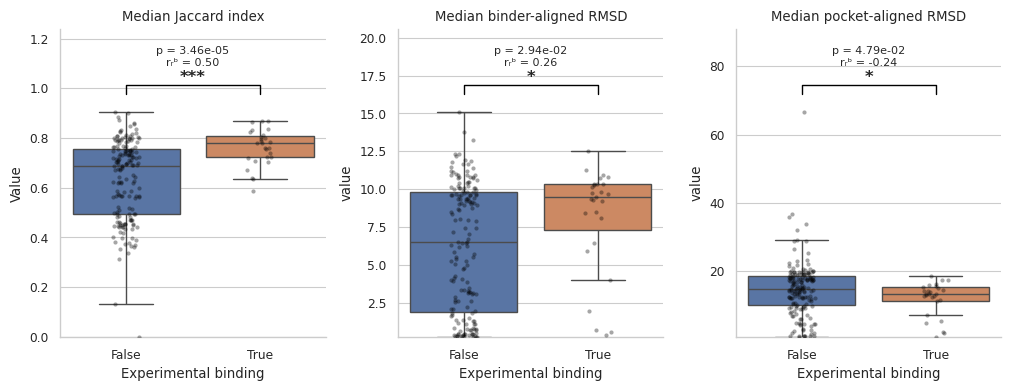

In [42]:
sns.set_theme(style="whitegrid", context="paper")

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    

plot_df = stats_df.melt(
    id_vars=["binder_sequence", "binding"],
    value_vars=[
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ],
    var_name="metric",
    value_name="value"
)

metric_labels = {
    "median_jaccard": "Median Jaccard index",
    "median_binder_aligned_rmsd": "Median binder-aligned RMSD",
    "median_pocket_aligned_rmsd": "Median pocket-aligned RMSD"
}

plot_df["metric"] = plot_df["metric"].map(metric_labels)

print(plot_df["binding"].dtype)
print(plot_df["binding"].unique())

palette = {
    False: "#4C72B0",
    True: "#DD8452"
}

g = sns.catplot(
    data=plot_df,
    x="binding",
    y="value",
    hue="binding",
    col="metric",
    kind="box",
    sharey=False,
    palette=palette,
    hue_order=[False, True],
    order=[False, True],
    height=4,
    aspect=0.85,
    showfliers=False,
    legend=False
)

g.set_axis_labels("Experimental binding", "Value")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    sns.stripplot(
        data=plot_df[plot_df["metric"] == ax.get_title()],
        x="binding",
        y="value",
        order=[False, True],
        color="black",
        alpha=0.35,
        size=3,
        jitter=True,
        ax=ax
    )

stats_lookup = {
    metric_labels[row["metric"]]: row
    for _, row in results.iterrows()
}

for ax in g.axes.flat:
    metric_name = ax.get_title()
    row = stats_lookup[metric_name]

    p = row["p_value"]   # or whatever your raw p-value column is called
    r_rb = row["rank_biserial"]
    stars = p_to_stars(p)

    sub = plot_df[plot_df["metric"] == metric_name]
    y_max = sub["value"].max()
    y_min = sub["value"].min()
    y_range = y_max - y_min

    # annotation height
    y = y_max + 0.08 * y_range
    h = 0.04 * y_range

    # bracket between False and True
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color="black", linewidth=1)

    # stars
    ax.text(
        0.5,
        y + h,
        stars,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    # statistical values
    ax.text(
        0.5,
        y + h + 0.08 * y_range,
        f"p = {p:.2e}\nr\u1d63\u1d47 = {r_rb:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

    # give space above plot
    ax.set_ylim(y_min, y + h + 0.25 * y_range)

sns.despine()
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler

model_df = stats_df.copy()

features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

model_df = model_df.dropna(subset=features + ["binding"])

scaler = StandardScaler()

z = pd.DataFrame(
    scaler.fit_transform(model_df[features]),
    columns=[f"{col}_z" for col in features],
    index=model_df.index
)

model_df = pd.concat([model_df, z], axis=1)

model_df["consensus_score"] = (
    model_df["median_jaccard_z"]
    - model_df["median_binder_aligned_rmsd_z"]
    - model_df["median_pocket_aligned_rmsd_z"]
)

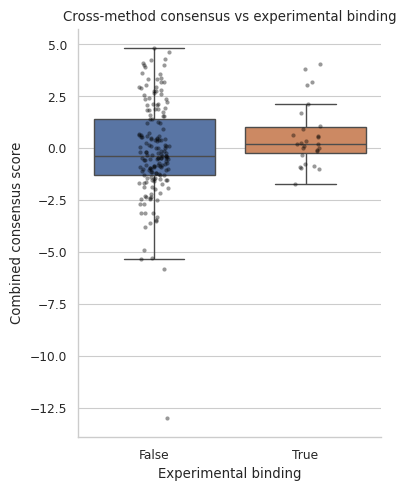

In [27]:
sns.set_theme(style="whitegrid", context="paper")

palette = {
    False: "#4C72B0",
    True: "#DD8452"
}

plt.figure(figsize=(4, 5))

ax = sns.boxplot(
    data=model_df,
    x="binding",
    y="consensus_score",
    hue="binding",
    palette=palette,
    order=[False, True],
    hue_order=[False, True],
    showfliers=False,
    legend=False
)

sns.stripplot(
    data=model_df,
    x="binding",
    y="consensus_score",
    order=[False, True],
    color="black",
    alpha=0.4,
    size=3,
    jitter=True,
    ax=ax
)

ax.set_xlabel("Experimental binding")
ax.set_ylabel("Combined consensus score")
ax.set_title("Cross-method consensus vs experimental binding")

sns.despine()
plt.tight_layout()
plt.show()

In [28]:
consensus_result = mannwhitney_with_effect_size(
    model_df,
    "consensus_score"
)

consensus_result

{'metric': 'consensus_score',
 'n_binders': 27,
 'n_non_binders': 170,
 'binder_median': np.float64(0.22807281186912345),
 'non_binder_median': np.float64(-0.3522792145695993),
 'U': np.float64(2811.0),
 'p_value': np.float64(0.0610430314636503),
 'rank_biserial': np.float64(0.22483660130718963)}

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, make_scorer, precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler


In [30]:
X = model_df[
    [
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ]
]

y = model_df["binding"].astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

summary = pd.DataFrame({
    metric: [
        cv_results[f"test_{metric}"].mean(),
        cv_results[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

summary

,mean,std
roc_auc,0.780588,0.126947
average_precision,0.437832,0.152108
balanced_accuracy,0.707647,0.133315
precision,0.259914,0.087677
recall,0.780000,0.226667
f1,0.386706,0.119204


In [31]:
feature_sets = {
    "Jaccard only": ["median_jaccard"],
    "Binder RMSD only": ["median_binder_aligned_rmsd"],
    "Pocket RMSD only": ["median_pocket_aligned_rmsd"],
    "Consensus score": [
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ],
    "equally weighted consensus": ["consensus_score"]
}

model_comparison = []

for name, cols in feature_sets.items():
    X_tmp = model_df[cols]
    y_tmp = model_df["binding"].astype(int)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

    scores = cross_validate(
        pipe,
        X_tmp,
        y_tmp,
        cv=cv,
        scoring=scoring
    )

    model_comparison.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean()
    })

model_comparison = pd.DataFrame(model_comparison)
model_comparison

,model,roc_auc_mean,roc_auc_std,f1_mean
0,Jaccard only,0.748627,0.151225,0.344367
1,Binder RMSD only,0.627255,0.139773,0.313171
2,Pocket RMSD only,0.629804,0.095379,0.241101
3,Consensus score,0.780588,0.126947,0.386706
4,equally weighted consensus,0.616078,0.092788,0.250476


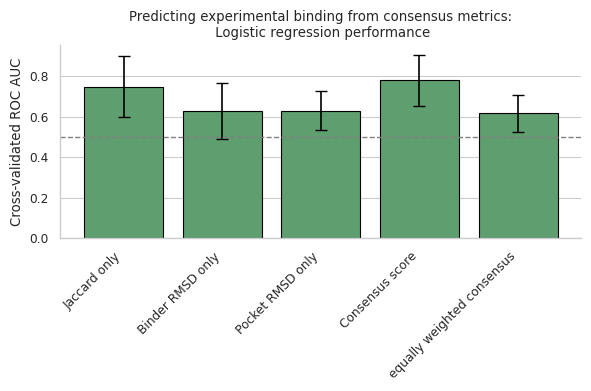

In [47]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=model_comparison,
    x="model",
    y="roc_auc_mean",
    edgecolor="black",
    color="#55A868"
)

ax.errorbar(
    x=range(len(model_comparison)),
    y=model_comparison["roc_auc_mean"],
    yerr=model_comparison["roc_auc_std"],
    fmt="none",
    color="black",
    capsize=4
)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)

ax.set_xlabel("")
ax.set_ylabel("Cross-validated ROC AUC")
ax.set_title("Predicting experimental binding from consensus metrics:\n Logistic regression performance")
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [33]:
final_features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_pipe.fit(model_df[final_features], y)

coefs = pd.DataFrame({
    "feature": final_features,
    "coefficient": final_pipe.named_steps["model"].coef_[0]
})

coefs

,feature,coefficient
0,median_jaccard,0.824023
1,median_binder_aligned_rmsd,0.874537
2,median_pocket_aligned_rmsd,-0.833701


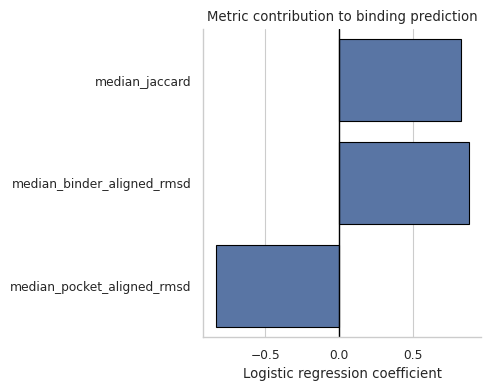

In [34]:
plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=coefs,
    x="coefficient",
    y="feature",
    edgecolor="black"
)

ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel("Logistic regression coefficient")
ax.set_ylabel("")
ax.set_title("Metric contribution to binding prediction")

sns.despine()
plt.tight_layout()
plt.show()

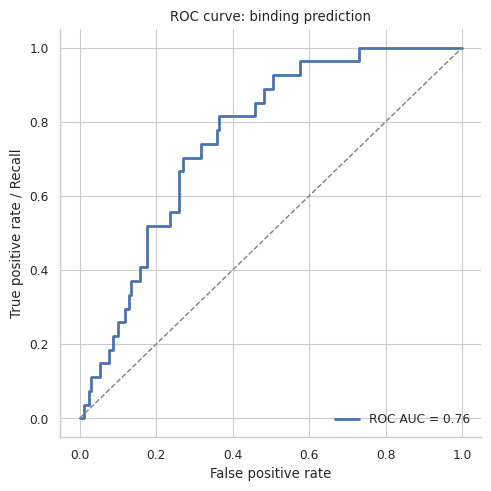

In [35]:
features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

X = model_df[features]
y = model_df["binding"].astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold predicted probabilities
y_score = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

fpr, tpr, _ = roc_curve(y, y_score)
roc_auc = auc(fpr, tpr)

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate / Recall")
plt.title("ROC curve: binding prediction")
plt.legend(frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

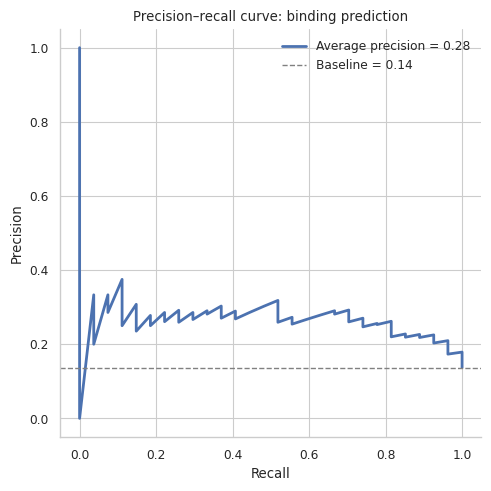

In [36]:
precision, recall, _ = precision_recall_curve(y, y_score)
avg_precision = average_precision_score(y, y_score)

baseline = y.mean()

plt.figure(figsize=(5, 5))

plt.plot(recall, precision, linewidth=2, label=f"Average precision = {avg_precision:.2f}")
plt.axhline(baseline, linestyle="--", linewidth=1, color="gray", label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–recall curve: binding prediction")
plt.legend(frameon=False, loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

In [37]:
binder_rmsd_target = (
    plot_pocket
    .groupby("binder_sequence", as_index=False)["binder_ca_rmsd_align_target_shell"]
    .median()
    .rename(columns={"binder_ca_rmsd_align_target_shell": "median_binder_rmsd_target_pocket"})
)

consensus_df_shell = binder_jaccard_summary.merge(
    binder_rmsd_target,
    on="binder_sequence",
    how="inner"
)

binder_df_target = (
    binder_jaccard_summary
    .merge(binder_rmsd_target, on="binder_sequence")
    .merge(binder_binding, on="binder_sequence")
)

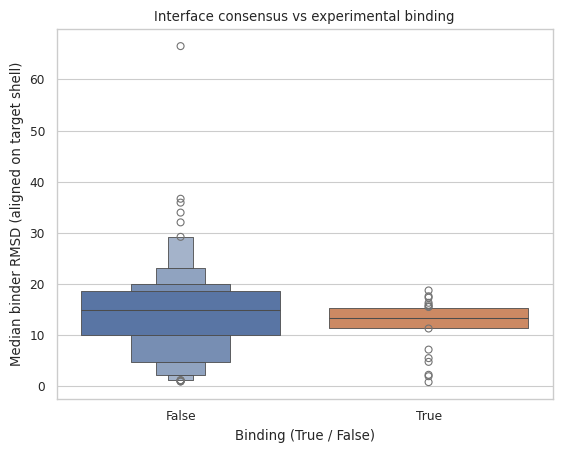

In [38]:
palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.boxenplot(
    data=binder_df_target,
    x="binding",
    y="median_binder_rmsd_target_pocket",
    hue="binding",
    palette=palette
)

plt.title("Interface consensus vs experimental binding")
plt.ylabel("Median binder RMSD (aligned on target shell)")
plt.xlabel("Binding (True / False)")
plt.legend().remove()
plt.show()

In [39]:
# Binding label (important: take one per binder)
# binder_binding = (
#     plot_rmsd[["binder_sequence", "binding"]]
#     .drop_duplicates()
# )

# Merge everything
binder_df = (
    binder_jaccard_summary
    .merge(binder_rmsd_summary, on="binder_sequence")
    .merge(binder_binding, on="binder_sequence")
)

binder_df.head()

,binder_sequence,median_jaccard,median_binder_aligned_rmsd,mean_binder_aligned_rmsd,binding
0,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,0.717277,0.522551,0.539935,False
1,AECPEEYKNYCKHGTCLYDVKKNKPVCLCDKGYLGPRCEKKDLSLLL,0.496154,2.854206,3.233216,False
2,AESHFSECPASLQNFCQNGTCRFHVGLNQPACICNRGYIGSRCELR...,0.807692,9.848934,6.449667,False
3,ANSYSPCPLEYKGYCKNGGVCVYIEATNTYACICVPGYYGPRCEYKDPK,0.642607,6.501615,5.118210,False
4,APLTEYEKKIEELWDVVHNVPDMEVRRKAIDLVFDLQVTHKITEEQ...,0.671875,0.570838,1.097305,True


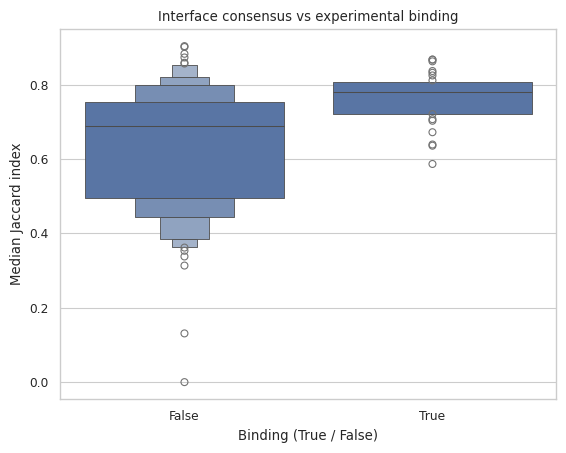

In [40]:
sns.boxenplot(
    data=binder_df,
    x="binding",
    y="median_jaccard"
)

plt.title("Interface consensus vs experimental binding")
plt.ylabel("Median Jaccard index")
plt.xlabel("Binding (True / False)")
plt.show()

In [41]:
sns.boxenplot(
    data=binder_df,
    x="binding",
    y="median_binder_rmsd"
)

plt.title("Fold consensus vs experimental binding")
plt.ylabel("Median binder RMSD")
plt.xlabel("Binding (True / False)")
plt.show()

ValueError: Could not interpret value `median_binder_rmsd` for `y`. An entry with this name does not appear in `data`.

In [ ]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    binder_df[binder_df["binding"] == True]["median_jaccard"],
    binder_df[binder_df["binding"] == False]["median_jaccard"]
)

print(p)

3.4635669573939245e-05


for a single binder-method structure, the distribution is effectively:

uniform over the contacted target residues and zero over all non-contacted residues

So for one binder:

if AF2 contacts 20 target residues, each gets roughly probability 1/20

if AF3 contacts 10 target residues, each gets roughly probability 1/10

it means KL is measuring:
how different the contacted target-residue sets are, plus how broad/narrow each interface is

In [ ]:
method_residue_matrix = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .unstack(fill_value=0)
)

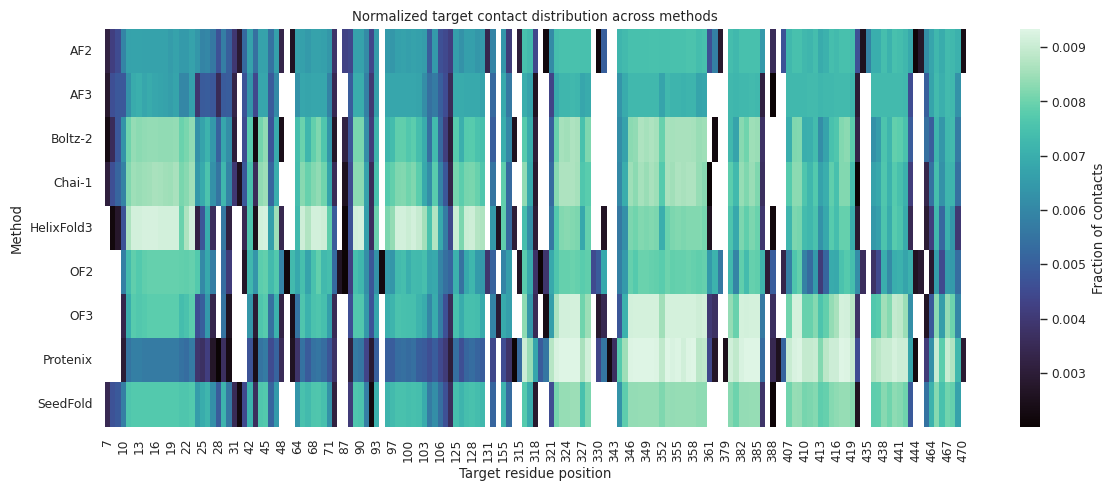

In [ ]:
# Normalize within each method
contact_fraction_matrix = (
    method_residue_matrix
    .div(method_residue_matrix.sum(axis=1), axis=0)
    .fillna(0)
)

# Set your visibility threshold
threshold = 0.002

# Keep only values above threshold
plot_matrix = contact_fraction_matrix.where(contact_fraction_matrix >= threshold)

# Drop residue columns where no method has a visible hit
plot_matrix = plot_matrix.loc[:, plot_matrix.notna().any(axis=0)]

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(12, 5))
ax = sns.heatmap(
    plot_matrix,
    cmap="mako",
    mask=plot_matrix.isna(),
    cbar_kws={"label": "Fraction of contacts"}
)

ax.set_xlabel("Target residue position")
ax.set_ylabel("Method")
ax.set_title("Normalized target contact distribution across methods")

plt.tight_layout()
plt.show()

In [ ]:
rmsd_mean = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)["binder_ca_rmsd_align_target_shell"]
    .mean()
)

rmsd_col = "binder_ca_rmsd_align_target_shell"

rmsd_median = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)[rmsd_col]
    .median()
    .rename(columns={rmsd_col: "pair_median_rmsd_pocket_aligned"})
)

rmsd_median.head()

,method_1,method_2,pair_median_rmsd_pocket_aligned
0,AF2,AF3,2.087449
1,AF2,Boltz-2,3.740203
2,AF2,Chai-1,3.035571
3,AF2,HelixFold3,13.412490
4,AF2,OF2,14.485943


In [ ]:
plot_rmsd_with_median = plot_rmsd.merge(rmsd_median, on=["method_1", "method_2"], how="left")

plot_rmsd_with_median.columns.to_list()

['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell',
 'design_class',
 'binding',
 'pair_median_rmsd_pocket_aligned']

In [ ]:
plot_rmsd_with_median[
    ["binder_sequence", "method_1", "method_2", "binder_ca_rmsd_align_binder", "binder_ca_rmsd_align_target_shell", "pair_median_rmsd_pocket_aligned"]
].head(20)

,binder_sequence,method_1,method_2,binder_ca_rmsd_align_binder,binder_ca_rmsd_align_target_shell,pair_median_rmsd_pocket_aligned
0,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,AF3,0.405979,0.687009,2.087449
1,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Boltz-2,0.717255,1.197764,3.740203
2,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Chai-1,0.518000,0.681339,3.035571
3,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,HelixFold3,0.490231,0.779947,13.412490
4,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,OF2,0.253574,0.312088,14.485943
5,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,OF3,0.343726,0.585104,13.599036
6,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Protenix,0.520128,0.992278,16.778810
7,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,SeedFold,0.524975,0.780936,2.125004
8,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF3,Boltz-2,0.541810,1.045234,4.285082
9,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF3,Chai-1,0.630850,0.911739,4.261712


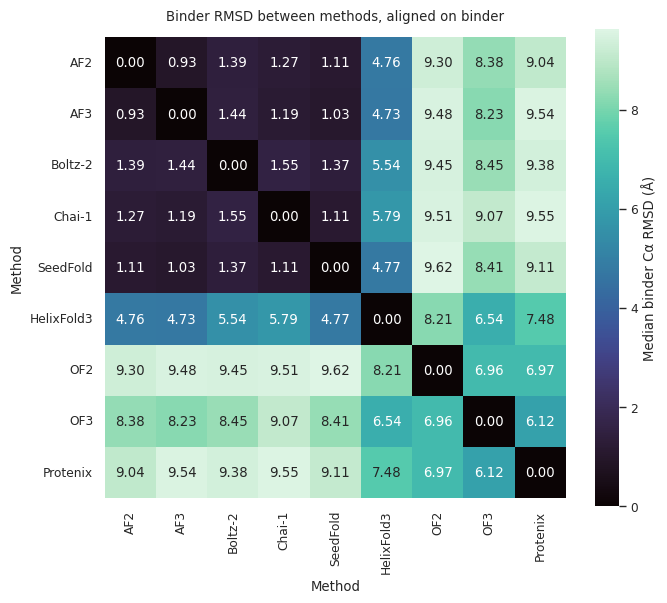

In [ ]:
rmsd_col = "binder_ca_rmsd_align_binder"

rmsd_matrix = (
    plot_rmsd
    .groupby(["method_1", "method_2"])[rmsd_col]
    .median()
    .unstack()
)

rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    rmsd_matrix,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

ax.set_title("Binder RMSD between methods, aligned on binder", pad=12)
ax.set_xlabel("Method")
ax.set_ylabel("Method")

plt.tight_layout()
plt.show()

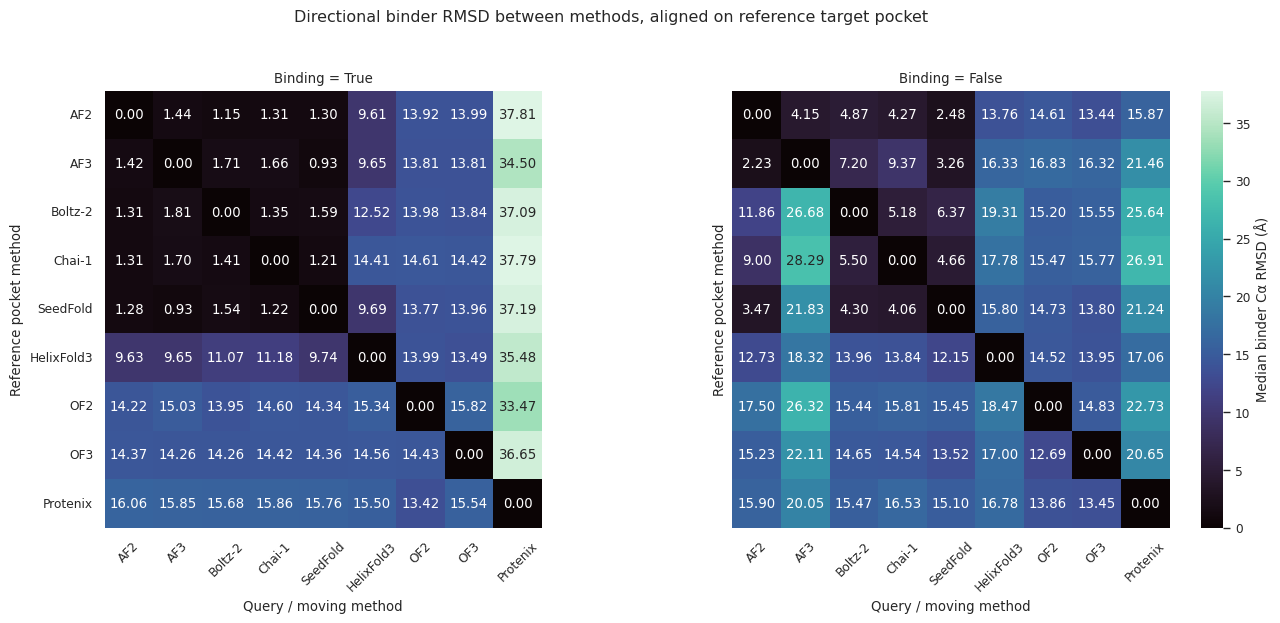

In [ ]:
rmsd_col = "binder_ca_rmsd_align_target_shell"

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

def make_rmsd_matrix(df):
    matrix = (
        df
        .groupby(["reference_method", "query_method"])[rmsd_col]
        .median()
        .unstack()
    )

    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 0.0

    return matrix

binding_matrix = make_rmsd_matrix(
    plot_pocket[plot_pocket["binding"] == True]
)

nonbinding_matrix = make_rmsd_matrix(
    plot_pocket[plot_pocket["binding"] == False]
)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(binding_matrix.min().min(), nonbinding_matrix.min().min())
vmax = max(binding_matrix.max().max(), nonbinding_matrix.max().max())

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Query / moving method")
    ax.set_ylabel("Reference pocket method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Directional binder RMSD between methods, aligned on reference target pocket",
    y=1.03
)

plt.tight_layout()
plt.show()

In [ ]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_target_shell"

plot_df = pocket_aligned_rmsd_df[
    pocket_aligned_rmsd_df["reference_method"] == ref
].copy()

# Paired table: one row per binder, one column per query method
pivot = plot_df.pivot(
    index="binder_sequence",
    columns="query_method",
    values=rmsd_col
)

# Summary medians
summary = (
    plot_df
    .groupby("query_method")[rmsd_col]
    .median()
    .reset_index(name="median_rmsd")
)

# Find best method = lowest median RMSD
best_method = (
    summary
    .sort_values("median_rmsd")
    .iloc[0]["query_method"]
)

print(f"Best method by median RMSD: {best_method}")

# Wilcoxon vs best method
stats = []

for method in pivot.columns:
    if method == best_method:
        continue

    sub = pivot[[best_method, method]].dropna()

    if len(sub) < 10:
        continue

    stat, p = wilcoxon(
        sub[method],
        sub[best_method],
        alternative="two-sided"
    )

    stats.append({
        "query_method": method,
        "n": len(sub),
        "p_value": p,
        "median_diff_vs_best": (sub[method] - sub[best_method]).median()
    })

stats_df = pd.DataFrame(stats)

if not stats_df.empty:
    stats_df["p_adj"] = multipletests(
        stats_df["p_value"],
        method="fdr_bh"
    )[1]
else:
    stats_df["p_adj"] = []

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

stats_df["stars"] = stats_df["p_adj"].apply(p_to_stars)

summary = summary.merge(
    stats_df[["query_method", "stars", "p_adj", "n", "median_diff_vs_best"]],
    on="query_method",
    how="left"
)

summary["stars"] = summary["stars"].fillna("")
summary["p_adj"] = summary["p_adj"].fillna(0)
summary["median_diff_vs_best"] = summary["median_diff_vs_best"].fillna(0)

# Sort bars by RMSD
order = (
    summary
    .sort_values("median_rmsd")
    ["query_method"]
    .tolist()
)

Best method by median RMSD: AF2


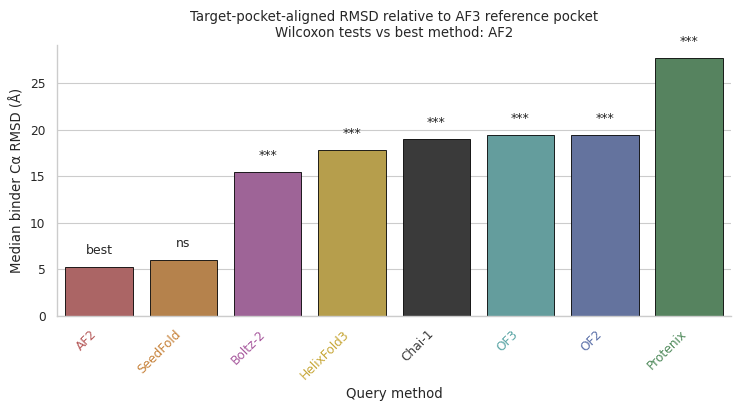

In [ ]:
palette = {
    "AF2": "#B65A5A",
    "SeedFold": "#C7823A",
    "HelixFold3": "#C8A83A",
    "Protenix": "#4F8A5B",
    "OF3": "#5BA6A6",
    "OF2": "#5A6FA8",
    "Chai-1": "#3A3A3A",
    "Boltz-2": "#A85A9E",
    "AF3": "#1F1F1F"
}

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(7.5, 4.2))

ax = sns.barplot(
    data=summary,
    x="query_method",
    y="median_rmsd",
    order=order,
    hue="query_method",
    palette=palette,
    dodge=False,
    edgecolor="black",
    linewidth=0.6,
    legend=False
)

# Add significance stars
y_offset = summary["median_rmsd"].max() * 0.04

for i, method in enumerate(order):
    row = summary[summary["query_method"] == method].iloc[0]

    label = row["stars"]

    # Do not label the best method against itself
    if method == best_method:
        label = "best"

    ax.text(
        i,
        row["median_rmsd"] + y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

# Color x tick labels by method
for label in ax.get_xticklabels():
    method = label.get_text()
    if method in palette:
        label.set_color(palette[method])

ax.set_xlabel("Query method")
ax.set_ylabel("Median binder Cα RMSD (Å)")
ax.set_title(
    f"Target-pocket-aligned RMSD relative to AF3 reference pocket\n"
    f"Wilcoxon tests vs best method: {best_method}"
)

plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_binder"  # adjust if needed

af3_as_1 = plot_rmsd[plot_rmsd["method_1"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["method_2"]

af3_as_2 = plot_rmsd[plot_rmsd["method_2"] == ref].copy()
af3_as_2["other_method"] = af3_as_2["method_1"]

af3_all = pd.concat([af3_as_1, af3_as_2], ignore_index=True)

print(sorted(af3_all["other_method"].unique()))

['AF2', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']


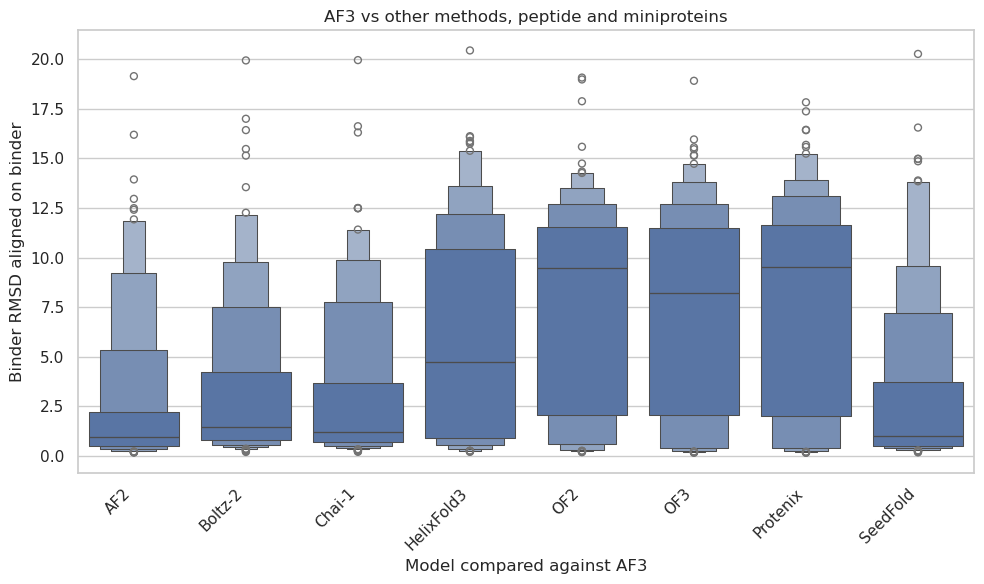

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=af3_all,
    x="other_method",
    y=rmsd_col,
    order=sorted(af3_all["other_method"].unique()),
    width_method="linear"
)

plt.xlabel("Model compared against AF3")
plt.ylabel("Binder RMSD aligned on binder")
plt.title("AF3 vs other methods, peptide and miniproteins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
(af3_all["binder_ca_rmsd_align_binder"] < 0).any()


np.False_

In [ ]:
chosen_seq = "SRLEEIVRETLRENGFSEEEIEHITWHFLLLWGSLERTYPHWSEEERVRRAAEYTQMMHPEITPEMVEKLVSRV"
rmsd_af3_all = af3_all[af3_all["binder_sequence"] == chosen_seq]

rmsd_af3_all[["method_1", "method_2", "binder_ca_rmsd_align_target_shell"]]

,method_1,method_2,binder_ca_rmsd_align_target_shell
1085,AF3,Boltz-2,5.394473
1086,AF3,Chai-1,17.987362
1087,AF3,HelixFold3,2.702815
1088,AF3,OF2,4.141567
1089,AF3,OF3,1.654907
1090,AF3,Protenix,2.731757
1091,AF3,SeedFold,1.616980
1534,AF2,AF3,0.943317


In [ ]:
print(af3_all.head())

                                     binder_sequence method_1    method_2  \
0  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3     Boltz-2   
1  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3      Chai-1   
2  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3  HelixFold3   
3  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3         OF2   
4  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3         OF3   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .cif        .cif   
1  /home/postyr/Assessing-AI-Scoring-Acc

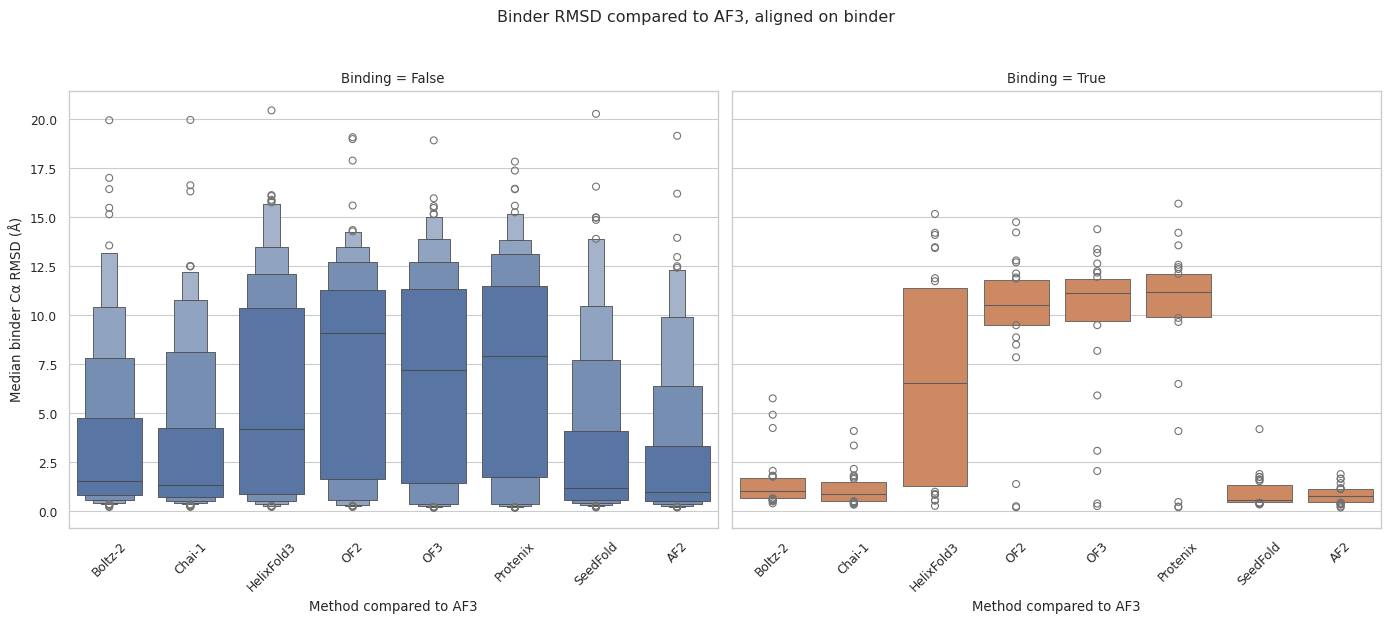

In [ ]:
sns.set_theme(style="whitegrid", context="paper")

af3_nonbinding = af3_all[af3_all["binding"] == False]
af3_binding = af3_all[af3_all["binding"] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)


sns.boxenplot(
    ax=axes[0],
    data=af3_nonbinding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#4C72B0",
    width_method="linear"
)


sns.boxenplot(
    ax=axes[1],
    data=af3_binding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#DD8452",
    width_method="linear"
)

axes[0].set_title("Binding = False")
axes[1].set_title("Binding = True")

for ax in axes:
    ax.set_ylabel("Median binder Cα RMSD (Å)")
    ax.set_xlabel("Method compared to AF3")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD compared to AF3, aligned on binder", y=1.03)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

rmsd_col = "binder_ca_rmsd_align_binder"

# Stack both columns into one unified "method" column
part1 = plot_rmsd[["method_1", rmsd_col]].rename(columns={"method_1": "method"})
part2 = plot_rmsd[["method_2", rmsd_col]].rename(columns={"method_2": "method"})

long_df = pd.concat([part1, part2], ignore_index=True)

summary = (
    long_df
    .groupby("method")[rmsd_col]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

print(summary)

                mean    median       std  count
method                                         
AF2         4.813116  2.577736  4.688113   1576
SeedFold    4.853085  2.904166  4.648256   1576
AF3         4.906886  2.239072  4.891615   1576
Boltz-2     5.077647  3.209745  4.595226   1576
Chai-1      5.122934  3.246712  4.673740   1576
HelixFold3  6.218858  6.136743  4.727907   1576
OF3         6.946753  7.575442  4.602364   1576
Protenix    7.059587  7.886349  4.673959   1576
OF2         7.377576  8.573551  4.565629   1576


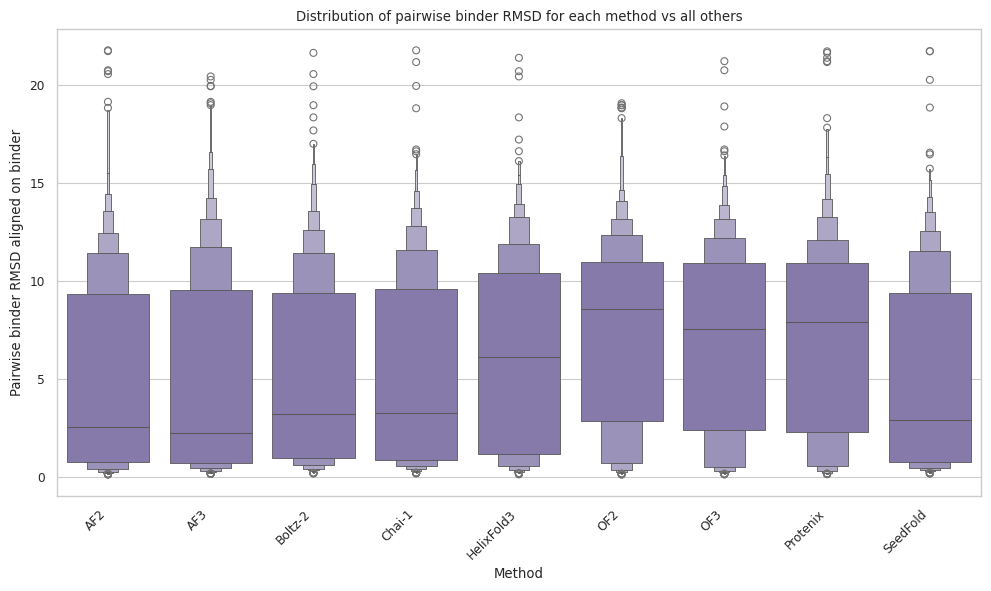

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.boxenplot(
    data=long_df,
    x="method",
    y=rmsd_col,
    color = "#8172B2"
)

plt.xlabel("Method")
plt.ylabel("Pairwise binder RMSD aligned on binder")
plt.title("Distribution of pairwise binder RMSD for each method vs all others")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

which methods tend to produce poses most similar to the overall consensus across binders?

The lower the Pairwise RMSD, the more in agreement the model is in general with the other models.